<a href="https://colab.research.google.com/github/tarkeshsingh/python-for-sensorimotor-control/blob/main/L8b_Eigenvectors_and_Eigenvalues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eigenvalues and Eigenvectors for Sensorimotor Control
## A Hands-On Tutorial for Movement Neuroscience Graduate Students

---

**Why this tutorial?**  
Section 11 of *L8 — Introduction to Linear Algebra* introduced eigendecomposition in a single page. This notebook slows down and unpacks it, because eigenvectors are the one piece of linear algebra you will meet again in almost every corner of movement neuroscience:

- **Variability structure:** the principal axes of an endpoint scatter or an error ellipse are eigenvectors of a covariance matrix
- **Neural dimensionality:** PCA of population activity *is* the eigendecomposition of a covariance matrix
- **Stability:** whether a limb, a reflex loop, or a cortical circuit settles or oscillates is written in the eigenvalues of its dynamics matrix
- **Learning timescales:** the fast and slow processes of motor adaptation are eigenvalues of a two-state learning model
- **Limb mechanics:** stiffness and inertia ellipses are eigenvectors of $K$ and $M$

Two ideas do all the work in this notebook. First, **eigenvectors of a covariance matrix describe *structure in variability*** — where the data spread. Second, **eigenvalues of a dynamics matrix describe *behaviour over time*** — how fast things decay, whether they oscillate, whether they blow up. Everything below is one of those two ideas wearing a different hat.

**Prerequisites:** Python Basics (L0), NumPy (L1), Matplotlib (L3), Linear Algebra (L8 §1–10).  
**Environment:** Google Colab (recommended) or Jupyter Notebook.

---


## Table of Contents

**Part I — Building Eigen-Intuition**
1. [What *Is* an Eigenvector?](#1)
2. [Computing Eigenvalues by Hand](#2)
3. [`np.linalg.eig` in Practice](#3)
4. [Symmetric Matrices and `eigh`](#4)

**Part II — Eigenvectors of Covariance: Structure in Variability**

5. [Endpoint Variability Ellipses](#5)
6. [PCA of a Neural Population](#6)
7. [How Many Dimensions? The Participation Ratio](#7)

**Part III — Eigenvalues of Dynamics: Behaviour Over Time**

8. [Stability of a Continuous-Time System](#8)
9. [Learning Timescales — The Two-State Model of Adaptation](#9)
10. [Arm Stiffness Ellipses](#10)
11. [When Eigenvalues Aren't Enough — Non-Normal Dynamics](#11)

**Part IV — Practical Guidance**

12. [Common Gotchas](#12)

**Part V — Practice**

13. [Exercises](#13)
14. [Summary & Further Reading](#14)


In [1]:
# ---- Setup ----

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig, eigh, eigvals, eigvalsh, inv, norm, det
from scipy.linalg import expm
from scipy.stats import chi2

# Print arrays at 3 decimals, no scientific notation — eigen-output is much easier to read this way
np.set_printoptions(precision=3, suppress=True)

---
# Part I — Building Eigen-Intuition

## 1. What *Is* an Eigenvector? <a id='1'></a>

A matrix $A$ takes a vector in and gives a different vector out. Usually the output points somewhere else — the matrix has **rotated** the vector. An **eigenvector** is one of the rare directions that survives untouched: the output points along the *same line* as the input, only stretched or squashed.

$$A \mathbf{v} = \lambda \mathbf{v}$$

The stretch factor $\lambda$ is the **eigenvalue**. Three things follow immediately, and they trip up everyone at first:

- Eigenvectors have **no unique length**. If $\mathbf{v}$ is an eigenvector, so is $2\mathbf{v}$, and so is $-\mathbf{v}$. NumPy returns unit-length ones, but the **sign is arbitrary** — a PC that points "up" in your analysis may point "down" on a colleague's machine running the same code.
- $\lambda$ can be **negative** (direction preserved, but flipped), **zero** (the direction is collapsed — $A$ is singular), or **complex** (the matrix rotates, so no real direction survives).
- Only **square** matrices have eigenvectors. For non-square data matrices you want the SVD (L8 §12).


In [2]:
# ---- The defining equation: A v = lambda v ----

A = np.array([[2.0, 1.0],
              [1.0, 2.0]])

v_eigen = np.array([1.0, 1.0]) / np.sqrt(2)   # An eigenvector (we will verify this)
v_other = np.array([1.0, 0.0])                # An ordinary direction

for name, v in [("v_eigen", v_eigen), ("v_other", v_other)]:
    Av = A @ v
    cos_angle = np.dot(Av, v) / (norm(Av) * norm(v))
    angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
    print(f"{name}: {v.round(3)} --A--> {Av.round(3)}")
    print(f"   rotated by {angle:5.2f}°, length scaled by {norm(Av)/norm(v):.3f}\n")

print("v_eigen came out rotated by 0° — the output is just a scaled copy of the input.")
print("That scale factor (3.0) is its eigenvalue.")

v_eigen: [0.707 0.707] --A--> [2.121 2.121]
   rotated by  0.00°, length scaled by 3.000

v_other: [1. 0.] --A--> [2. 1.]
   rotated by 26.57°, length scaled by 2.236

v_eigen came out rotated by 0° — the output is just a scaled copy of the input.
That scale factor (3.0) is its eigenvalue.


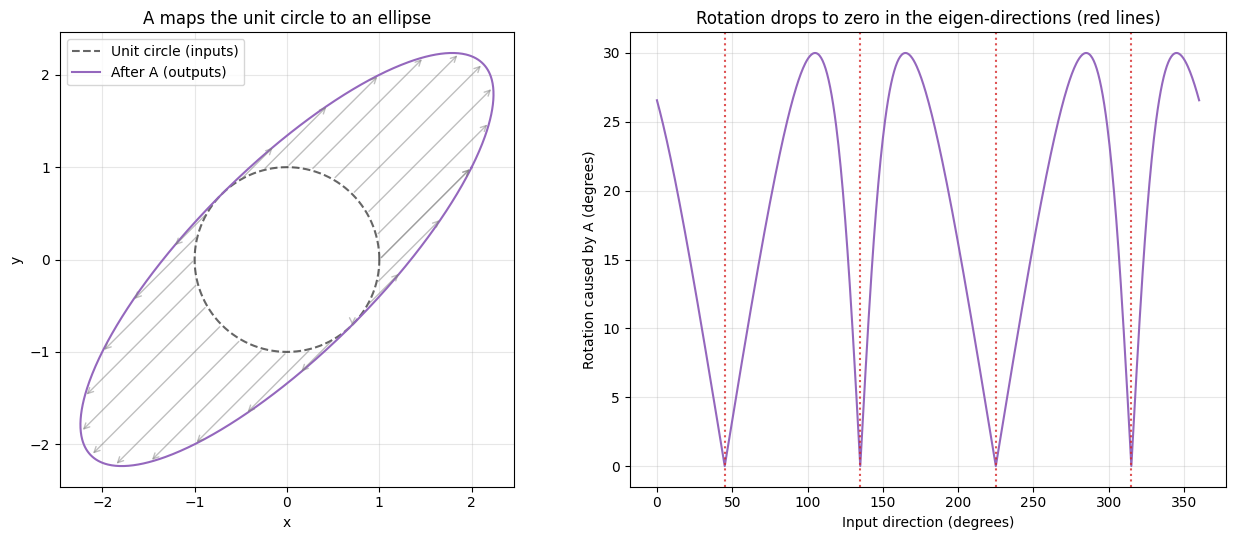

Directions rotated by (essentially) 0°: [ 45. 135. 225. 315.] degrees


In [3]:
# ---- Which directions survive the transformation unrotated? ----
# Push every direction on the unit circle through A and measure how much each one rotates.

theta = np.linspace(0, 2*np.pi, 721)
circle = np.column_stack([np.cos(theta), np.sin(theta)])   # (721, 2) unit vectors
mapped = (A @ circle.T).T                                  # Each vector after A

cosines = np.sum(circle * mapped, axis=1) / (norm(circle, axis=1) * norm(mapped, axis=1))
rotation = np.degrees(np.arccos(np.clip(cosines, -1, 1)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left panel: the unit circle becomes an ellipse
axes[0].plot(circle[:, 0], circle[:, 1], 'k--', alpha=0.6, label='Unit circle (inputs)')
axes[0].plot(mapped[:, 0], mapped[:, 1], color='tab:purple', label='After A (outputs)')
for k in range(0, 721, 30):
    axes[0].annotate('', xy=mapped[k], xytext=circle[k],
                     arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))
axes[0].set_aspect('equal')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('A maps the unit circle to an ellipse')
axes[0].legend(loc='upper left'); axes[0].grid(True, alpha=0.3)

# Right panel: rotation as a function of input direction
axes[1].plot(np.degrees(theta), rotation, color='tab:purple')
for d in [45, 135, 225, 315]:
    axes[1].axvline(d, color='tab:red', linestyle=':', alpha=0.8)
axes[1].set_xlabel('Input direction (degrees)')
axes[1].set_ylabel('Rotation caused by A (degrees)')
axes[1].set_title('Rotation drops to zero in the eigen-directions (red lines)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fixed = np.degrees(theta[rotation < 1e-6])
print(f"Directions rotated by (essentially) 0°: {np.unique(fixed.round(0))} degrees")

Two lessons from that figure, and both matter later:

1. **A matrix turns a circle into an ellipse.** This is why ellipses show up everywhere in this notebook — variability ellipses, stiffness ellipses, confidence ellipses. They are all the image of a circle under some matrix, and the eigenvectors are the ellipse axes.
2. **The eigen-directions are where rotation vanishes**, at 45° and 225° (the same line, opposite signs) and at 135° and 315°. For this symmetric $A$ they are perpendicular. That is not a coincidence — see §4.


---
## 2. Computing Eigenvalues by Hand <a id='2'></a>

You will use `np.linalg.eig` for everything real, but working one 2×2 case by hand makes the output far less mysterious.

Rearranging $A\mathbf{v} = \lambda\mathbf{v}$ gives $(A - \lambda I)\mathbf{v} = \mathbf{0}$. A non-zero $\mathbf{v}$ can only satisfy this if $A - \lambda I$ squashes some direction to nothing — that is, if it is singular:

$$\det(A - \lambda I) = 0$$

For a 2×2 matrix this expands into a tidy quadratic:

$$\lambda^2 - \underbrace{\text{tr}(A)}_{a_{11}+a_{22}}\lambda + \underbrace{\det(A)}_{a_{11}a_{22}-a_{12}a_{21}} = 0$$


In [4]:
# ---- Characteristic equation for a 2x2 matrix ----

tr, dt = np.trace(A), det(A)
print(f"trace(A) = {tr:.1f},  det(A) = {dt:.1f}")
print(f"Characteristic polynomial:  λ² - {tr:.0f}λ + {dt:.0f} = 0\n")

discriminant = tr**2 - 4*dt
lam1 = (tr + np.sqrt(discriminant)) / 2
lam2 = (tr - np.sqrt(discriminant)) / 2

print(f"By hand: λ1 = {lam1:.3f}, λ2 = {lam2:.3f}")
print(f"NumPy:   {np.sort(eigvals(A))[::-1]}")

trace(A) = 4.0,  det(A) = 3.0
Characteristic polynomial:  λ² - 4λ + 3 = 0

By hand: λ1 = 3.000, λ2 = 1.000
NumPy:   [3. 1.]


In [5]:
# ---- Two sanity checks worth running on EVERY eigendecomposition ----
# They cost one line each and catch most indexing mistakes.

vals = eigvals(A)
print(f"Sum of eigenvalues should equal the trace:       {vals.sum():.4f}  vs  {np.trace(A):.4f}")
print(f"Product of eigenvalues should equal the det:     {np.prod(vals):.4f}  vs  {det(A):.4f}")

Sum of eigenvalues should equal the trace:       4.0000  vs  4.0000
Product of eigenvalues should equal the det:     3.0000  vs  3.0000


In [6]:
# ---- Finding the eigenvector for a known eigenvalue ----
# Solve (A - λI)v = 0 — i.e. find the null space direction of (A - λI).

lam = 3.0
M = A - lam*np.eye(2)
print(f"A - 3I =\n{M}")
print(f"rank = {np.linalg.matrix_rank(M)}  (rank-deficient, so a non-zero solution exists)")

# Row 1 says -1*v1 + 1*v2 = 0, so v1 = v2. Any multiple of [1, 1] works:
v = np.array([1.0, 1.0]) / np.sqrt(2)
print(f"\nCheck: (A - 3I) @ v = {(M @ v).round(12)}   (the zero vector)")
print(f"Check: A @ v = {(A @ v).round(3)} = 3 × {v.round(3)}")

A - 3I =
[[-1.  1.]
 [ 1. -1.]]
rank = 1  (rank-deficient, so a non-zero solution exists)

Check: (A - 3I) @ v = [0. 0.]   (the zero vector)
Check: A @ v = [2.121 2.121] = 3 × [0.707 0.707]


---
## 3. `np.linalg.eig` in Practice <a id='3'></a>

`eig` returns a tuple `(eigenvalues, eigenvectors)`. The single most common bug in student code:

> **Eigenvectors are the COLUMNS of the returned matrix, not the rows.**

`evecs[:, 0]` is the eigenvector for `evals[0]`. `evecs[0, :]` is meaningless. And unlike `eigh` (§4), **`eig` does not sort its output** — never assume the first eigenvalue is the largest.


In [7]:
# ---- Reading the output of np.linalg.eig ----
# A non-symmetric example: the state-transition matrix of a discrete-time system.

T = np.array([[0.60, 0.25],
              [0.10, 0.90]])

evals, evecs = eig(T)

print(f"eigenvalues:  {evals}")
print(f"eigenvectors:\n{evecs}\n")
print(f"Eigenvector for λ={evals[0]:.3f} is the FIRST COLUMN: {evecs[:, 0].round(3)}")
print(f"Eigenvector for λ={evals[1]:.3f} is the SECOND COLUMN: {evecs[:, 1].round(3)}")
print(f"Every column has unit length: {norm(evecs, axis=0).round(6)}")

eigenvalues:  [0.532 0.968]
eigenvectors:
[[-0.965 -0.562]
 [ 0.262 -0.827]]

Eigenvector for λ=0.532 is the FIRST COLUMN: [-0.965  0.262]
Eigenvector for λ=0.968 is the SECOND COLUMN: [-0.562 -0.827]
Every column has unit length: [1. 1.]


In [8]:
# ---- Always verify: does A v = λ v actually hold? ----

for i in range(len(evals)):
    lhs = T @ evecs[:, i]
    rhs = evals[i] * evecs[:, i]
    print(f"λ{i+1} = {evals[i]:7.3f} | A v = {lhs.round(4)} | λ v = {rhs.round(4)} | match: {np.allclose(lhs, rhs)}")

λ1 =   0.532 | A v = [-0.513  0.14 ] | λ v = [-0.513  0.14 ] | match: True
λ2 =   0.968 | A v = [-0.544 -0.801] | λ v = [-0.544 -0.801] | match: True


In [9]:
# ---- A sorting helper we will reuse throughout the notebook ----

def sorted_eig(A, symmetric=False):
    """Eigendecomposition with eigenvalues sorted largest-magnitude first.

    Parameters
    ----------
    A : (n, n) array
    symmetric : bool
        Use True for covariance, stiffness, inertia — anything symmetric.
        This calls eigh, which is faster, returns real values, and guarantees
        orthogonal eigenvectors (see Section 4).

    Returns
    -------
    vals : (n,) eigenvalues, descending by |lambda|
    vecs : (n, n) eigenvectors as COLUMNS, matched to vals
    """
    vals, vecs = (eigh(A) if symmetric else eig(A))
    order = np.argsort(np.abs(vals))[::-1]
    return vals[order], vecs[:, order]


vals, vecs = sorted_eig(T)
print(f"Sorted eigenvalues: {vals}")
print(f"Dominant direction (largest |λ|): {vecs[:, 0].round(3)}")

Sorted eigenvalues: [0.968 0.532]
Dominant direction (largest |λ|): [-0.562 -0.827]


In [10]:
# ---- The eigendecomposition: A = V Λ V^(-1) ----
# Rebuilding A from its eigen-parts is the best proof you have read the output correctly.

V = vecs
Lam = np.diag(vals)
A_rebuilt = V @ Lam @ inv(V)

print(f"Original T:\n{T}")
print(f"\nRebuilt V Λ V⁻¹:\n{np.real_if_close(A_rebuilt).round(6)}")
print(f"\nIdentical? {np.allclose(T, np.real_if_close(A_rebuilt))}")

# Why inv(V) and not V.T? Because T is not symmetric, its eigenvectors are not perpendicular:
cos_between = np.dot(V[:, 0], V[:, 1]) / (norm(V[:, 0]) * norm(V[:, 1]))
print(f"\nAngle between the two eigenvectors: {np.degrees(np.arccos(np.clip(cos_between, -1, 1))):.1f}°")
print("Not 90° — so V.T is NOT the inverse here. Use inv(V) for non-symmetric matrices.")

Original T:
[[0.6  0.25]
 [0.1  0.9 ]]

Rebuilt V Λ V⁻¹:
[[0.6  0.25]
 [0.1  0.9 ]]

Identical? True

Angle between the two eigenvectors: 71.0°
Not 90° — so V.T is NOT the inverse here. Use inv(V) for non-symmetric matrices.


---
## 4. Symmetric Matrices and `eigh` <a id='4'></a>

Most matrices you meet in data analysis are **symmetric**: covariance matrices, correlation matrices, stiffness matrices, inertia matrices. Symmetric matrices are extremely well behaved, and NumPy has a dedicated routine for them.

| | `np.linalg.eig` | `np.linalg.eigh` |
|---|---|---|
| Input | any square matrix | symmetric (or Hermitian) only |
| Eigenvalues | may be complex | always **real** |
| Eigenvectors | generally **not** orthogonal | always **orthonormal** ($V^TV = I$) |
| Ordering | arbitrary | **ascending** |
| Inverse in $A = V\Lambda V^{-1}$ | needs `inv(V)` | just `V.T` |
| Speed & numerical stability | slower, less stable | faster, more stable |

**Use `eigh` whenever the matrix is symmetric.** With `eig` you get tiny imaginary residues like `4.2+0.j` that then poison downstream arithmetic and plotting.


In [11]:
# ---- eig vs eigh on the same symmetric matrix ----

C = np.array([[4.0, 1.5],
              [1.5, 1.0]])          # A covariance matrix: symmetric by construction

vals_eig,  vecs_eig  = eig(C)
vals_eigh, vecs_eigh = eigh(C)

print(f"eig  eigenvalues: {vals_eig}   dtype={vals_eig.dtype}")
print(f"eigh eigenvalues: {vals_eigh}   dtype={vals_eigh.dtype}   <- real, and ascending")
print(f"\neigh eigenvectors:\n{vecs_eigh}")
print(f"\nOrthonormal? V.T @ V =\n{(vecs_eigh.T @ vecs_eigh).round(12)}")
print(f"\nSo the inverse is just the transpose: V Λ V.T rebuilds C? "
      f"{np.allclose(vecs_eigh @ np.diag(vals_eigh) @ vecs_eigh.T, C)}")

eig  eigenvalues: [4.621 0.379]   dtype=float64
eigh eigenvalues: [0.379 4.621]   dtype=float64   <- real, and ascending

eigh eigenvectors:
[[ 0.383 -0.924]
 [-0.924 -0.383]]

Orthonormal? V.T @ V =
[[ 1. -0.]
 [-0.  1.]]

So the inverse is just the transpose: V Λ V.T rebuilds C? True


In [12]:
# ---- Why it matters at scale: speed on a realistic covariance matrix ----
# 200 neurons -> a 200x200 covariance matrix. Nothing exotic these days.

from time import perf_counter

rng = np.random.default_rng(42)
X = rng.normal(size=(1000, 200))
S = np.cov(X, rowvar=False)          # (200, 200), symmetric

t0 = perf_counter(); eig(S);  t_eig  = perf_counter() - t0
t0 = perf_counter(); eigh(S); t_eigh = perf_counter() - t0

print(f"eig  on a 200×200 symmetric matrix: {t_eig*1000:7.1f} ms")
print(f"eigh on a 200×200 symmetric matrix: {t_eigh*1000:7.1f} ms")
print(f"Speed-up: {t_eig/t_eigh:.1f}×  (and eigh returns clean real numbers)")

eig  on a 200×200 symmetric matrix:   321.8 ms
eigh on a 200×200 symmetric matrix:    94.4 ms
Speed-up: 3.4×  (and eigh returns clean real numbers)


---
# Part II — Eigenvectors of Covariance: Structure in Variability

## 5. Endpoint Variability Ellipses <a id='5'></a>

Ask a participant to reach repeatedly to the same target and the endpoints scatter. That scatter is almost never circular: it is typically elongated **along** the direction of the reach, because errors in movement extent and errors in movement direction come from partly different sources.

The covariance matrix $\Sigma$ of the endpoints contains that structure, but reading it off the raw numbers is hard. Eigendecomposition converts it into something interpretable:

- **eigenvectors** → the principal axes of the scatter (the directions of most and least variability)
- **eigenvalues** → the *variance* along each of those axes, so $\sqrt{\lambda}$ is the **standard deviation** in cm

That square root matters. A common student error is to draw ellipse axes proportional to $\lambda$ when the data are variances — the ellipse then looks far more elongated than the data actually are.


In [13]:
# ---- Simulate reach endpoints with anisotropic variability ----

rng = np.random.default_rng(7)

reach_angle = 60.0                     # Reach direction (degrees from +x axis)
sd_along, sd_perp = 2.4, 0.9           # SD parallel and perpendicular to the reach (cm)

th = np.radians(reach_angle)
R = np.array([[np.cos(th), -np.sin(th)],
              [np.sin(th),  np.cos(th)]])

# Build a covariance with known principal axes, then rotate it into the reach direction
Sigma_true = R @ np.diag([sd_along**2, sd_perp**2]) @ R.T
endpoints = rng.multivariate_normal([0, 0], Sigma_true, size=250)   # Errors relative to target

Sigma_hat = np.cov(endpoints, rowvar=False)     # rowvar=False: rows are observations, columns are variables
print(f"Sample covariance (cm²):\n{Sigma_hat}")

vals, vecs = sorted_eig(Sigma_hat, symmetric=True)
print(f"\nEigenvalues (variances, cm²): {vals}")
print(f"Eigenvectors (columns):\n{vecs}")
print(f"\nSD along PC1: {np.sqrt(vals[0]):.2f} cm   (simulated: {sd_along} cm)")
print(f"SD along PC2: {np.sqrt(vals[1]):.2f} cm   (simulated: {sd_perp} cm)")
print(f"Anisotropy (SD ratio PC1/PC2): {np.sqrt(vals[0]/vals[1]):.2f}")

pc1_angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0])) % 180
print(f"\nPC1 orientation: {pc1_angle:.1f}°   |   Reach direction: {reach_angle:.1f}°")
print(f"Misalignment: {abs(pc1_angle - reach_angle):.1f}°")

Sample covariance (cm²):
[[1.847 1.949]
 [1.949 4.004]]

Eigenvalues (variances, cm²): [5.153 0.699]
Eigenvectors (columns):
[[ 0.508 -0.861]
 [ 0.861  0.508]]

SD along PC1: 2.27 cm   (simulated: 2.4 cm)
SD along PC2: 0.84 cm   (simulated: 0.9 cm)
Anisotropy (SD ratio PC1/PC2): 2.72

PC1 orientation: 59.5°   |   Reach direction: 60.0°
Misalignment: 0.5°


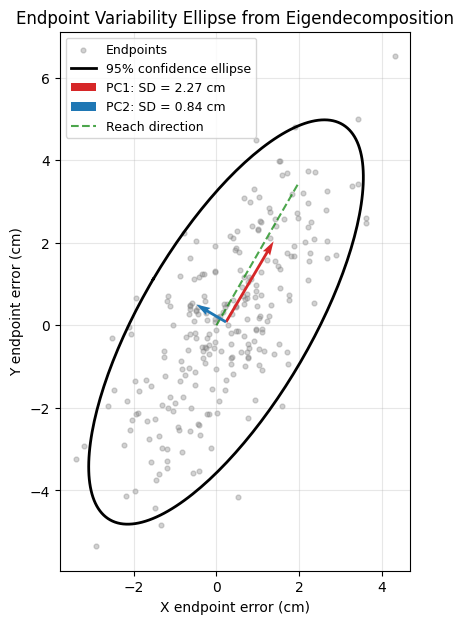

In [14]:
# ---- Draw the 95% confidence ellipse from the eigendecomposition ----
# The ellipse is the unit circle, stretched by sqrt(eigenvalue) along each eigenvector,
# then scaled by a chi-square factor for the desired coverage.

def covariance_ellipse(mean, cov, n_sd=None, coverage=0.95, n_points=200):
    """Return (n_points, 2) boundary points of a covariance ellipse."""
    vals, vecs = eigh(cov)                       # eigh: ascending, orthonormal
    scale = n_sd if n_sd is not None else np.sqrt(chi2.ppf(coverage, df=2))
    t = np.linspace(0, 2*np.pi, n_points)
    circle = np.column_stack([np.cos(t), np.sin(t)])
    return mean + circle @ (vecs * (scale * np.sqrt(vals))).T


mean = endpoints.mean(axis=0)
ellipse95 = covariance_ellipse(mean, Sigma_hat, coverage=0.95)

plt.figure(figsize=(7, 7))
plt.scatter(endpoints[:, 0], endpoints[:, 1], s=12, alpha=0.35, color='gray', label='Endpoints')
plt.plot(ellipse95[:, 0], ellipse95[:, 1], 'k-', linewidth=2, label='95% confidence ellipse')

colors = ['tab:red', 'tab:blue']
for i in range(2):
    axis = vecs[:, i] * np.sqrt(vals[i])       # One SD along this principal axis
    plt.quiver(*mean, *axis, angles='xy', scale_units='xy', scale=1,
               color=colors[i], width=0.008, zorder=5,
               label=f'PC{i+1}: SD = {np.sqrt(vals[i]):.2f} cm')

# Reach direction for comparison
plt.plot([0, 4*np.cos(th)], [0, 4*np.sin(th)], 'g--', alpha=0.7, label='Reach direction')
plt.gca().set_aspect('equal')
plt.xlabel('X endpoint error (cm)')
plt.ylabel('Y endpoint error (cm)')
plt.title('Endpoint Variability Ellipse from Eigendecomposition')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# ---- Check the ellipse actually contains 95% of the data ----
# Mahalanobis distance squared is chi-square distributed with df = 2 in the plane.

d = endpoints - mean
mahalanobis_sq = np.sum((d @ inv(Sigma_hat)) * d, axis=1)
inside = mahalanobis_sq <= chi2.ppf(0.95, df=2)

print(f"Points inside the 95% ellipse: {inside.sum()}/{len(endpoints)} = {100*inside.mean():.1f}%")
print("\nA '2 SD' ellipse is NOT the 95% ellipse in 2-D:")
print(f"  chi2 scale factor for 95% coverage in 2-D: {np.sqrt(chi2.ppf(0.95, df=2)):.3f} SD")
print(f"  a 2.0 SD ellipse actually covers:          {100*chi2.cdf(2.0**2, df=2):.1f}%")

Points inside the 95% ellipse: 236/250 = 94.4%

A '2 SD' ellipse is NOT the 95% ellipse in 2-D:
  chi2 scale factor for 95% coverage in 2-D: 2.448 SD
  a 2.0 SD ellipse actually covers:          86.5%


---
## 6. PCA of a Neural Population <a id='6'></a>

Record 60 neurons and you have a 60-dimensional dataset, but the population almost never uses all 60 dimensions: neurons are correlated, so the activity lives on a low-dimensional surface inside that space. **PCA is exactly the eigendecomposition of the neural covariance matrix**, and it finds that surface.

The recipe never changes:

1. Arrange data as **(observations × variables)** — here time bins × neurons
2. **Centre** it (subtract each neuron's mean rate). Skip this and PC1 just points at the mean firing rate
3. Compute the covariance matrix (neurons × neurons)
4. `eigh`, then sort descending
5. Project the centred data onto the leading eigenvectors to get **PC scores**


In [16]:
# ---- Simulate a neural population driven by 3 latent factors ----

rng = np.random.default_rng(0)
n_neurons, n_bins = 60, 400
t = np.linspace(0, 2.0, n_bins)                 # 2 seconds of a reach, 5 ms bins

# The "true" low-dimensional signal: a rotation (as in motor cortex) plus a slow ramp
latents = np.column_stack([np.sin(2*np.pi*1.0*t),
                           np.cos(2*np.pi*1.0*t),
                           1.5 * t / t.max()])

W = rng.normal(0, 1, size=(n_neurons, 3))       # How strongly each neuron loads on each latent
X = 20 + 5 * (latents @ W.T) + rng.normal(0, 1.2, size=(n_bins, n_neurons))

print(f"Data matrix X: {X.shape}  (time bins × neurons)")
print(f"True latent dimensionality: {latents.shape[1]}")

Data matrix X: (400, 60)  (time bins × neurons)
True latent dimensionality: 3


In [17]:
# ---- PCA by eigendecomposition of the covariance matrix ----

X_c = X - X.mean(axis=0)                        # Step 2: centre each neuron
C_neural = np.cov(X_c, rowvar=False)            # Step 3: (60, 60) covariance
print(f"Covariance matrix: {C_neural.shape}")

vals, vecs = sorted_eig(C_neural, symmetric=True)   # Steps 1 & 4
var_explained = 100 * vals / vals.sum()
scores = X_c @ vecs[:, :3]                      # Step 5: (400, 3) PC scores

print(f"\nVariance explained by the first 6 PCs: {var_explained[:6].round(1)} %")
print(f"Cumulative:                            {np.cumsum(var_explained[:6]).round(1)} %")
print(f"\nPCs needed for 90% of the variance: {np.argmax(np.cumsum(var_explained) >= 90) + 1}")

Covariance matrix: (60, 60)

Variance explained by the first 6 PCs: [53.8 29.3 12.3  0.2  0.1  0.1] %
Cumulative:                            [53.8 83.  95.3 95.5 95.6 95.8] %

PCs needed for 90% of the variance: 3


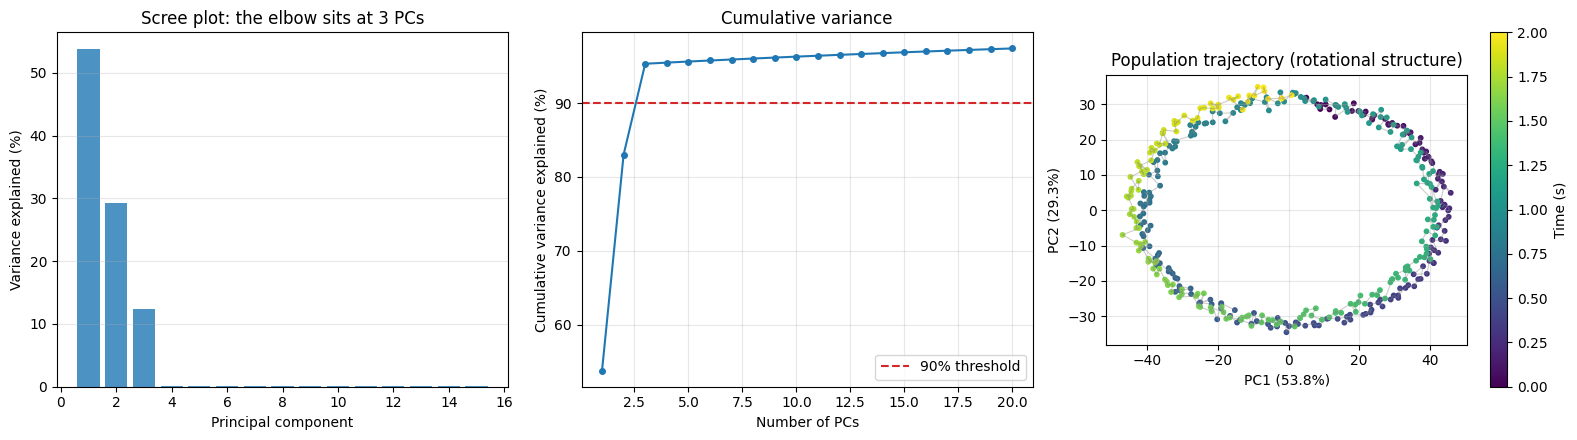

In [18]:
# ---- Visualize the spectrum and the low-dimensional trajectory ----

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Scree plot
axes[0].bar(np.arange(1, 16), var_explained[:15], color='tab:blue', alpha=0.8)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Scree plot: the elbow sits at 3 PCs')
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative variance
axes[1].plot(np.arange(1, 21), np.cumsum(var_explained[:20]), 'o-', color='tab:blue', markersize=4)
axes[1].axhline(90, color='tab:red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative variance explained (%)')
axes[1].set_title('Cumulative variance')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Neural trajectory in the PC1-PC2 plane
sc = axes[2].scatter(scores[:, 0], scores[:, 1], c=t, cmap='viridis', s=10)
axes[2].plot(scores[:, 0], scores[:, 1], color='gray', alpha=0.4, linewidth=0.8)
axes[2].set_xlabel(f'PC1 ({var_explained[0]:.1f}%)')
axes[2].set_ylabel(f'PC2 ({var_explained[1]:.1f}%)')
axes[2].set_title('Population trajectory (rotational structure)')
axes[2].set_aspect('equal')
plt.colorbar(sc, ax=axes[2], label='Time (s)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# ---- PCA via eigendecomposition and PCA via SVD are the same thing ----
# SVD of the centred data is numerically preferable; the connection is:
#     singular value σ_i  ->  eigenvalue λ_i = σ_i² / (n - 1)

U, sigma, Vt = np.linalg.svd(X_c, full_matrices=False)
vals_from_svd = sigma**2 / (n_bins - 1)

print(f"Eigenvalues of the covariance matrix: {vals[:5].round(4)}")
print(f"σ² / (n-1) from the SVD:              {vals_from_svd[:5].round(4)}")
print(f"\nSame? {np.allclose(vals[:5], vals_from_svd[:5])}")
print("\nAlso note: the PC directions are the rows of Vt (up to an arbitrary sign flip).")
print(f"|dot product| between PC1 from eigh and PC1 from SVD: {abs(np.dot(vecs[:, 0], Vt[0])):.6f}")

Eigenvalues of the covariance matrix: [930.774 506.903 213.123   2.611   2.562]
σ² / (n-1) from the SVD:              [930.774 506.903 213.123   2.611   2.562]

Same? True

Also note: the PC directions are the rows of Vt (up to an arbitrary sign flip).
|dot product| between PC1 from eigh and PC1 from SVD: 1.000000


---
## 7. How Many Dimensions? The Participation Ratio <a id='7'></a>

"How many PCs should I keep?" has no single right answer, but the scree-plot-elbow eyeball test is the weakest option available. Two better habits:

**The participation ratio** summarises the whole eigenvalue spectrum in one number:

$$\text{PR} = \frac{\left(\sum_i \lambda_i\right)^2}{\sum_i \lambda_i^2}$$

If one eigenvalue dominates, PR ≈ 1. If all $n$ are equal, PR = $n$. It is continuous, requires no threshold, and is the standard summary of neural dimensionality.

**A shuffled control** tells you what the spectrum would look like with the correlations destroyed. Shuffle each neuron's activity independently in time: the single-neuron statistics are preserved, the population structure is not. Any eigenvalue that stands above the shuffled spectrum reflects genuine population structure.


In [20]:
# ---- Participation ratio, plus a shuffled null distribution ----

def participation_ratio(vals):
    """Effective dimensionality from an eigenvalue spectrum."""
    vals = np.asarray(vals, dtype=float)
    return vals.sum()**2 / (vals**2).sum()


# Shuffle each neuron independently in time -> destroys correlations, keeps each neuron's variance
rng = np.random.default_rng(1)
X_shuffled = np.column_stack([rng.permutation(col) for col in X_c.T])
vals_shuf, _ = sorted_eig(np.cov(X_shuffled, rowvar=False), symmetric=True)

print(f"Real data — participation ratio: {participation_ratio(vals):.2f}")
print(f"Shuffled  — participation ratio: {participation_ratio(vals_shuf):.2f}")
print(f"Number of neurons:               {n_neurons}")
print(f"\nPCs above the shuffled ceiling:  {(vals > vals_shuf[0]).sum()}   (true latent count: 3)")

Real data — participation ratio: 2.57
Shuffled  — participation ratio: 37.02
Number of neurons:               60

PCs above the shuffled ceiling:  3   (true latent count: 3)


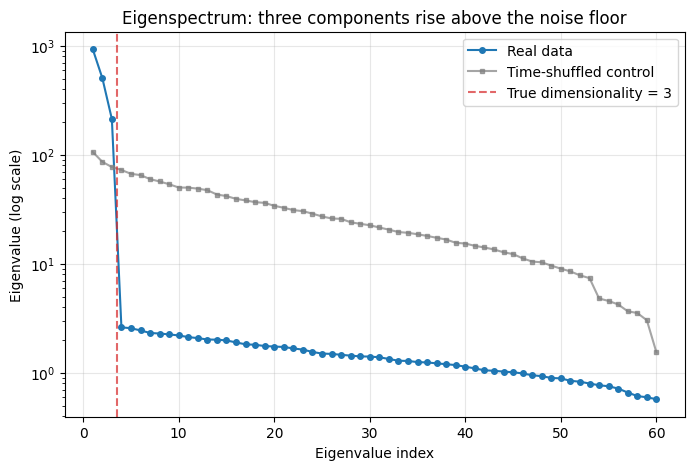

In [21]:
# ---- Plot the real vs shuffled eigenvalue spectrum ----

plt.figure(figsize=(8, 5))
plt.semilogy(np.arange(1, n_neurons+1), vals, 'o-', color='tab:blue', markersize=4, label='Real data')
plt.semilogy(np.arange(1, n_neurons+1), vals_shuf, 's-', color='tab:gray', markersize=3,
             alpha=0.7, label='Time-shuffled control')
plt.axvline(3.5, color='tab:red', linestyle='--', alpha=0.7, label='True dimensionality = 3')
plt.xlabel('Eigenvalue index')
plt.ylabel('Eigenvalue (log scale)')
plt.title('Eigenspectrum: three components rise above the noise floor')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

---
# Part III — Eigenvalues of Dynamics: Behaviour Over Time

## 8. Stability of a Continuous-Time System <a id='8'></a>

For a linear system $\dot{x} = Ax$, the eigenvalues of $A$ *are* the behaviour. Write $x(0)$ in the eigenvector basis and each component evolves independently as $e^{\lambda t}$:

$$x(t) = \sum_i c_i \, e^{\lambda_i t} \, \mathbf{v}_i$$

So each eigenvalue $\lambda = a + bi$ contributes one mode:

| Eigenvalue | Behaviour of that mode | Time constant |
|---|---|---|
| $a < 0$, $b = 0$ | smooth exponential decay | $\tau = -1/a$ |
| $a < 0$, $b \neq 0$ | **damped oscillation** at $b/2\pi$ Hz | $\tau = -1/a$ |
| $a = 0$ | marginal — neither decays nor grows | — |
| $a > 0$ | **unstable**: grows without bound | — |

The **slowest** mode (the eigenvalue closest to the imaginary axis) dominates late behaviour, so the system's overall time constant is $-1/\max_i \text{Re}(\lambda_i)$.


In [22]:
# ---- Mass-spring-damper: how eigenvalues move as damping changes ----
# State x = [position, velocity].  Think of it as a limb held at a posture.

m, k = 1.0, 4.0                        # Mass (kg), stiffness (N/m)

def system_matrix(b):
    """Continuous-time dynamics matrix for damping coefficient b."""
    return np.array([[0.0,   1.0],
                     [-k/m, -b/m]])

b_values = np.linspace(0, 6, 300)
spectra = np.array([np.sort_complex(eigvals(system_matrix(b))) for b in b_values])

b_critical = 2*np.sqrt(k*m)            # Critical damping
print(f"Critical damping b_c = 2√(km) = {b_critical:.2f} N·s/m")

for b in [0.0, 0.5, 4.0, 6.0]:
    ev = eigvals(system_matrix(b))
    zeta = b / (2*np.sqrt(k*m))
    kind = ("undamped" if zeta == 0 else "underdamped" if zeta < 1
            else "critically damped" if np.isclose(zeta, 1) else "overdamped")
    print(f"b = {b:4.1f} (ζ = {zeta:.2f}, {kind:18s}): λ = {ev.round(3)}")

Critical damping b_c = 2√(km) = 4.00 N·s/m
b =  0.0 (ζ = 0.00, undamped          ): λ = [ 0.+2.j -0.-2.j]
b =  0.5 (ζ = 0.12, underdamped       ): λ = [-0.25+1.984j -0.25-1.984j]
b =  4.0 (ζ = 1.00, critically damped ): λ = [-2. -2.]
b =  6.0 (ζ = 1.50, overdamped        ): λ = [-0.764 -5.236]


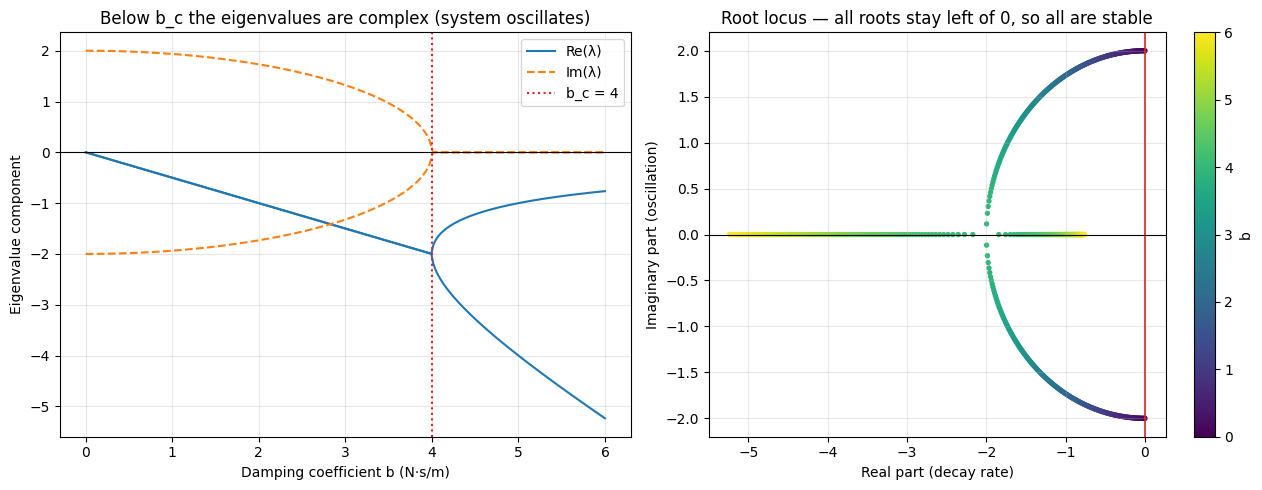

In [23]:
# ---- Root locus: the eigenvalues trace a path through the complex plane ----

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(b_values, spectra.real[:, 0], color='tab:blue', label='Re(λ)')
axes[0].plot(b_values, spectra.real[:, 1], color='tab:blue')
axes[0].plot(b_values, spectra.imag[:, 0], color='tab:orange', linestyle='--', label='Im(λ)')
axes[0].plot(b_values, spectra.imag[:, 1], color='tab:orange', linestyle='--')
axes[0].axvline(b_critical, color='tab:red', linestyle=':', label=f'b_c = {b_critical:.0f}')
axes[0].axhline(0, color='k', linewidth=0.8)
axes[0].set_xlabel('Damping coefficient b (N·s/m)')
axes[0].set_ylabel('Eigenvalue component')
axes[0].set_title('Below b_c the eigenvalues are complex (system oscillates)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(spectra.real.ravel(), spectra.imag.ravel(),
                     c=np.repeat(b_values, 2), cmap='viridis', s=8)
axes[1].axvline(0, color='tab:red', linewidth=1.2)
axes[1].axhline(0, color='k', linewidth=0.8)
axes[1].set_xlabel('Real part (decay rate)')
axes[1].set_ylabel('Imaginary part (oscillation)')
axes[1].set_title('Root locus — all roots stay left of 0, so all are stable')
plt.colorbar(sc, ax=axes[1], label='b')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Eigenvalues: [-0.25+1.984j -0.25-1.984j]
Decay time constant τ = -1/Re(λ) = 4.00 s
Damped oscillation frequency     = 0.316 Hz

Max difference between the modal solution and expm: 1.98e-15


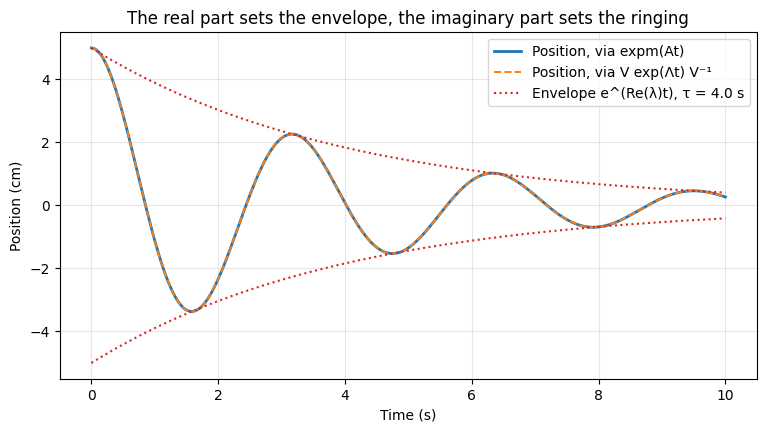

In [24]:
# ---- Eigenvalues don't just describe the solution — they ARE the solution ----
# x(t) = V exp(Λt) V⁻¹ x(0).  Compare against the matrix exponential.

b = 0.5
A_sys = system_matrix(b)
vals_s, vecs_s = eig(A_sys)
x0 = np.array([0.05, 0.0])              # 5 cm initial displacement, at rest

t_sim = np.linspace(0, 10, 500)
c = inv(vecs_s) @ x0                    # Initial condition in the eigenvector basis
x_modal = np.real(vecs_s @ (c[:, None] * np.exp(np.outer(vals_s, t_sim))))
x_expm = np.column_stack([expm(A_sys*ti) @ x0 for ti in t_sim])

print(f"Eigenvalues: {vals_s.round(4)}")
print(f"Decay time constant τ = -1/Re(λ) = {-1/vals_s[0].real:.2f} s")
print(f"Damped oscillation frequency     = {abs(vals_s[0].imag)/(2*np.pi):.3f} Hz")
print(f"\nMax difference between the modal solution and expm: {np.abs(x_modal - x_expm).max():.2e}")

plt.figure(figsize=(9, 4.5))
plt.plot(t_sim, x_expm[0]*100, color='tab:blue', linewidth=2, label='Position, via expm(At)')
plt.plot(t_sim, x_modal[0]*100, '--', color='tab:orange', linewidth=1.4,
         label='Position, via V exp(Λt) V⁻¹')
plt.plot(t_sim, 5*np.exp(vals_s[0].real*t_sim), color='tab:red', linestyle=':',
         label=f'Envelope e^(Re(λ)t), τ = {-1/vals_s[0].real:.1f} s')
plt.plot(t_sim, -5*np.exp(vals_s[0].real*t_sim), color='tab:red', linestyle=':')
plt.xlabel('Time (s)'); plt.ylabel('Position (cm)')
plt.title('The real part sets the envelope, the imaginary part sets the ringing')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

> **Discrete time works the same way, but the stability boundary moves.** Trial-by-trial models step forward as $x_{n+1} = A x_n$, so mode $i$ evolves as $\lambda_i^n$ instead of $e^{\lambda_i t}$. Stability then requires $|\lambda_i| < 1$ — inside the **unit circle** — rather than a negative real part. Section 9 is a discrete-time model, so watch for that switch.


---
## 9. Learning Timescales — The Two-State Model of Adaptation <a id='9'></a>

Motor adaptation is not one process. Smith, Ghazizadeh & Shadmehr (2006) proposed that at least two run in parallel: a **fast** process that learns quickly but forgets quickly, and a **slow** process that learns weakly but retains well. On trial $n$, with error $e_n$:

$$x^f_{n+1} = A_f x^f_n + B_f e_n, \qquad x^s_{n+1} = A_s x^s_n + B_s e_n$$

The motor output is $z_n = x^f_n + x^s_n$ and the error is $e_n = p_n - z_n$ for a perturbation $p_n$. Substituting the error back in couples the two states, giving the closed-loop dynamics

$$\mathbf{x}_{n+1} = \underbrace{\left( \begin{pmatrix} A_f & 0 \\ 0 & A_s \end{pmatrix} - \begin{pmatrix} B_f \\ B_s \end{pmatrix}\begin{pmatrix} 1 & 1 \end{pmatrix} \right)}_{A_{\text{closed}}} \mathbf{x}_n + \begin{pmatrix} B_f \\ B_s \end{pmatrix} p_n$$

**The eigenvalues of $A_\text{closed}$ are the learning timescales**, converted to trials by $\tau = -1/\ln|\lambda|$.


In [25]:
# ---- Build the two-state model and read off its timescales ----

Af, Bf = 0.850, 0.120      # Fast process: poor retention (A), high error sensitivity (B)
As, Bs = 0.995, 0.015      # Slow process: strong retention, low error sensitivity

A_open = np.diag([Af, As])
B = np.array([Bf, Bs])
A_closed = A_open - np.outer(B, [1.0, 1.0])

print(f"Open-loop A (retention only):\n{A_open}")
print(f"\nClosed-loop A (learning from error):\n{A_closed.round(4)}")

vals_l, vecs_l = sorted_eig(A_closed)
tau = -1 / np.log(np.abs(vals_l))

print(f"\nClosed-loop eigenvalues: {vals_l.round(4)}")
print(f"Stable? all |λ| < 1: {np.all(np.abs(vals_l) < 1)}   |λ| = {np.abs(vals_l).round(4)}")
print(f"\nLearning time constants: {tau.round(1)} trials")
print(f"  slow mode: {tau.max():.0f} trials    fast mode: {tau.min():.1f} trials")
print(f"  ratio of timescales: {tau.max()/tau.min():.0f}×")
print(f"\nEigenvectors (columns):\n{vecs_l.round(3)}")
print("A_closed is not symmetric, so these are not orthogonal — the modes are mixtures")
print("of the fast and slow states, not the states themselves.")

Open-loop A (retention only):
[[0.85  0.   ]
 [0.    0.995]]

Closed-loop A (learning from error):
[[ 0.73  -0.12 ]
 [-0.015  0.98 ]]

Closed-loop eigenvalues: [0.987 0.723]
Stable? all |λ| < 1: True   |λ| = [0.987 0.723]

Learning time constants: [76.4  3.1] trials
  slow mode: 76 trials    fast mode: 3.1 trials
  ratio of timescales: 25×

Eigenvectors (columns):
[[ 0.423 -0.998]
 [-0.906 -0.058]]
A_closed is not symmetric, so these are not orthogonal — the modes are mixtures
of the fast and slow states, not the states themselves.


In [26]:
# ---- Simulate adaptation -> washout -> error clamp ----
# The classic test: after adaptation and a brief washout, clamp the error to zero.
# A one-state learner would stay flat. A two-state learner rebounds.

# The washout is deliberately brief: just long enough to drive the OUTPUT back to zero,
# which is precisely the trick — the output is zero while the two states are not.
n_adapt, n_wash, n_clamp = 150, 5, 150

perturbation = np.concatenate([np.ones(n_adapt), -np.ones(n_wash), np.zeros(n_clamp)])
is_clamped = np.concatenate([np.zeros(n_adapt + n_wash, dtype=bool), np.ones(n_clamp, dtype=bool)])

x = np.zeros(2)
states, outputs, errors = [], [], []

for n in range(len(perturbation)):
    z = x.sum()                                        # Motor output = fast + slow
    e = 0.0 if is_clamped[n] else perturbation[n] - z  # Error clamp means zero error
    states.append(x.copy()); outputs.append(z); errors.append(e)
    x = A_open @ x + B * e                             # Update both states

states = np.array(states)
outputs = np.array(outputs)

print(f"Adaptation at end of training: {outputs[n_adapt-1]:.3f}")
print(f"Output at the end of washout:  {outputs[n_adapt+n_wash-1]:.3f}   (back to ~zero)")
print(f"  but the internal states are NOT zero: fast = {states[n_adapt+n_wash-1, 0]:.3f}, "
      f"slow = {states[n_adapt+n_wash-1, 1]:.3f}")
print(f"Peak rebound during the error clamp: {outputs[n_adapt+n_wash:].max():.3f} "
      f"at clamp trial {outputs[n_adapt+n_wash:].argmax()+1}")

Adaptation at end of training: 0.746
Output at the end of washout:  0.030   (back to ~zero)
  but the internal states are NOT zero: fast = -0.416, slow = 0.446
Peak rebound during the error clamp: 0.370 at clamp trial 24


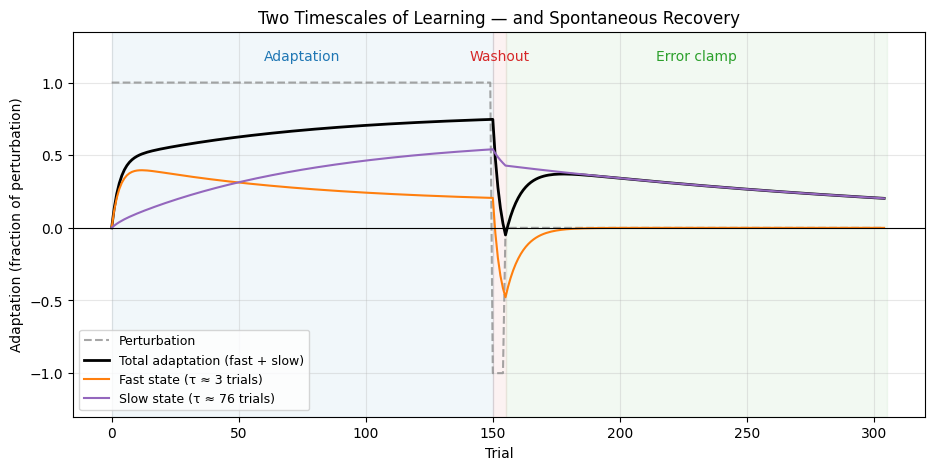

In [27]:
# ---- Plot the spontaneous recovery ----

trials = np.arange(len(perturbation))

plt.figure(figsize=(11, 5))
plt.axvspan(0, n_adapt, color='tab:blue', alpha=0.06)
plt.axvspan(n_adapt, n_adapt+n_wash, color='tab:red', alpha=0.06)
plt.axvspan(n_adapt+n_wash, len(trials), color='tab:green', alpha=0.06)

plt.plot(trials, perturbation, color='gray', linestyle='--', alpha=0.7, label='Perturbation')
plt.plot(trials, outputs, 'k-', linewidth=2, label='Total adaptation (fast + slow)')
plt.plot(trials, states[:, 0], color='tab:orange', linewidth=1.5, label=f'Fast state (τ ≈ {tau.min():.0f} trials)')
plt.plot(trials, states[:, 1], color='tab:purple', linewidth=1.5, label=f'Slow state (τ ≈ {tau.max():.0f} trials)')
plt.axhline(0, color='k', linewidth=0.8)

plt.text(n_adapt/2, 1.15, 'Adaptation', ha='center', color='tab:blue')
plt.text(n_adapt + n_wash/2, 1.15, 'Washout', ha='center', color='tab:red')
plt.text(n_adapt + n_wash + n_clamp/2, 1.15, 'Error clamp', ha='center', color='tab:green')

plt.xlabel('Trial'); plt.ylabel('Adaptation (fraction of perturbation)')
plt.title('Two Timescales of Learning — and Spontaneous Recovery')
plt.legend(loc='lower left', fontsize=9); plt.grid(True, alpha=0.3)
plt.ylim(-1.3, 1.35)
plt.show()

The rebound in the green region is **spontaneous recovery**, and it is a purely eigen-phenomenon. At the end of washout the total output is near zero, but that zero is a *cancellation*: the fast state is strongly negative and the slow state is still positive. Once the error is clamped, learning stops and the two states simply decay at their own rates — $\lambda_\text{fast}$ quickly, $\lambda_\text{slow}$ slowly. The fast state vanishes first, unmasking the slow state, and adaptation re-appears from nothing.

A single-state model cannot produce this at any parameter value. **Two well-separated eigenvalues can.**


---
## 10. Arm Stiffness Ellipses <a id='10'></a>

Hold your hand at a posture and have someone push it. The restoring force is approximately linear in the displacement:

$$\mathbf{F} = -K \mathbf{d}$$

where $K$ is the 2×2 **hand stiffness matrix** (N/m). Its eigen-structure is the standard way to report postural stiffness (Mussa-Ivaldi, Hogan & Bizzi, 1985):

- **eigenvectors** → the directions of maximum and minimum stiffness
- **eigenvalues** → the stiffness (N/m) along each of those directions

Note the contrast with §5. For a *covariance* matrix the ellipse axes go as $\sqrt{\lambda}$, because variance has squared units. For a *mapping* matrix like $K$ the axes go as $\lambda$ itself. Getting this backwards is the single most common eigen-plotting error.


In [28]:
# ---- Hand stiffness: eigenvalues give the principal stiffnesses ----

K = np.array([[250.0, -80.0],
              [-80.0, 120.0]])          # N/m, symmetric

vals_k, vecs_k = sorted_eig(K, symmetric=True)

print(f"Stiffness matrix K (N/m):\n{K}")
print(f"\nPrincipal stiffnesses: {vals_k.round(1)} N/m")
print(f"Stiffest direction:  {vecs_k[:, 0].round(3)}  at "
      f"{np.degrees(np.arctan2(vecs_k[1,0], vecs_k[0,0])) % 180:.1f}°")
print(f"Most compliant direction: {vecs_k[:, 1].round(3)}  at "
      f"{np.degrees(np.arctan2(vecs_k[1,1], vecs_k[0,1])) % 180:.1f}°")
print(f"\nShape (stiffness ratio k_max/k_min): {vals_k[0]/vals_k[1]:.2f}")
print(f"Size (mean stiffness, = trace/2):    {np.trace(K)/2:.1f} N/m")
print(f"All eigenvalues positive? {np.all(vals_k > 0)}  -> the posture is stable")

# Real measured stiffness matrices are rarely exactly symmetric. Symmetrise before eigh:
K_measured = np.array([[250.0, -74.0], [-86.0, 124.0]])
K_sym = (K_measured + K_measured.T) / 2
print(f"\nA measured (asymmetric) K, symmetrised:\n{K_sym}")

Stiffness matrix K (N/m):
[[250. -80.]
 [-80. 120.]]

Principal stiffnesses: [288.1  81.9] N/m
Stiffest direction:  [-0.903  0.43 ]  at 154.5°
Most compliant direction: [-0.43  -0.903]  at 64.5°

Shape (stiffness ratio k_max/k_min): 3.52
Size (mean stiffness, = trace/2):    185.0 N/m
All eigenvalues positive? True  -> the posture is stable

A measured (asymmetric) K, symmetrised:
[[250. -80.]
 [-80. 124.]]


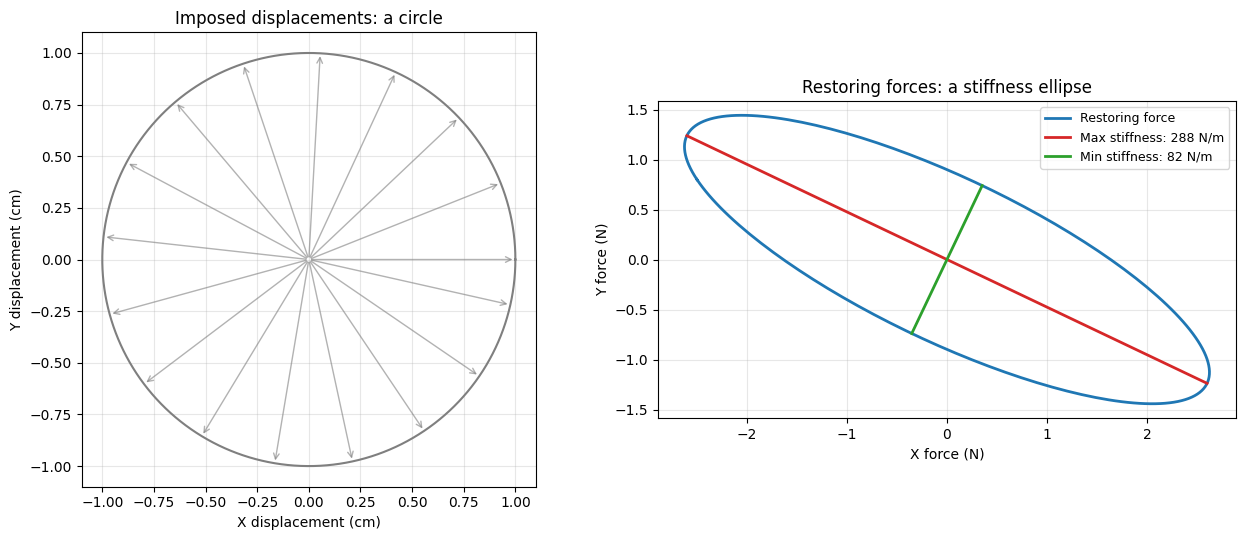

In [29]:
# ---- Push the hand in every direction and plot the restoring force ----

t_circ = np.linspace(0, 2*np.pi, 200)
d_unit = 0.01 * np.column_stack([np.cos(t_circ), np.sin(t_circ)])   # 1 cm displacements
F = -(K @ d_unit.T).T                                              # Restoring forces (N)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(d_unit[:, 0]*100, d_unit[:, 1]*100, color='tab:gray')
for j in range(0, 200, 12):
    axes[0].annotate('', xy=(d_unit[j, 0]*100, d_unit[j, 1]*100), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='tab:gray', alpha=0.6))
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('X displacement (cm)'); axes[0].set_ylabel('Y displacement (cm)')
axes[0].set_title('Imposed displacements: a circle')

axes[1].plot(F[:, 0], F[:, 1], color='tab:blue', linewidth=2, label='Restoring force')
for i, col in enumerate(['tab:red', 'tab:green']):
    axis = vecs_k[:, i] * vals_k[i] * 0.01
    axes[1].plot([-axis[0], axis[0]], [-axis[1], axis[1]], color=col, linewidth=2,
                 label=f'{"Max" if i == 0 else "Min"} stiffness: {vals_k[i]:.0f} N/m')
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('X force (N)'); axes[1].set_ylabel('Y force (N)')
axes[1].set_title('Restoring forces: a stiffness ellipse')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 11. When Eigenvalues Aren't Enough — Non-Normal Dynamics <a id='11'></a>

Everything in §8 assumed the eigenvectors give a sensible coordinate system. When a matrix is **non-normal** ($AA^T \neq A^TA$), its eigenvectors are nearly parallel rather than perpendicular, and the eigenvalues stop telling the whole story.

The consequence is important for neuroscience: **a system can have every eigenvalue firmly stable and still amplify an input enormously before decaying.** Cortical circuits, where strong recurrent excitation is stabilised by feedback inhibition, are strongly non-normal, and this "balanced amplification" is one proposed mechanism for how spontaneous activity gets structured (Murphy & Miller, 2009).

The diagnostic is the **symmetric part** $\tfrac{1}{2}(A + A^T)$. If its largest eigenvalue is positive, some direction grows transiently, no matter how stable the eigenvalues of $A$ look.


In [30]:
# ---- Two systems with IDENTICAL eigenvalues but opposite behaviour ----

A_normal = np.array([[-0.10,  0.00],
                     [ 0.00, -0.20]])

A_nonnormal = np.array([[-0.10, 0.00],
                        [ 8.00, -0.20]])     # A strong feedforward connection

print(f"Eigenvalues of A_normal:     {np.sort(eigvals(A_normal)).round(3)}")
print(f"Eigenvalues of A_nonnormal:  {np.sort(eigvals(A_nonnormal)).round(3)}   <- identical, both stable")

for name, A_x in [('A_normal', A_normal), ('A_nonnormal', A_nonnormal)]:
    is_normal = np.allclose(A_x @ A_x.T, A_x.T @ A_x)
    sym_max = eigvalsh((A_x + A_x.T)/2).max()
    print(f"\n{name}: normal? {is_normal}")
    print(f"   largest eigenvalue of the symmetric part: {sym_max:+.3f} "
          f"({'transient growth possible' if sym_max > 0 else 'monotonic decay'})")

Eigenvalues of A_normal:     [-0.2 -0.1]
Eigenvalues of A_nonnormal:  [-0.2 -0.1]   <- identical, both stable

A_normal: normal? True
   largest eigenvalue of the symmetric part: -0.100 (monotonic decay)

A_nonnormal: normal? False
   largest eigenvalue of the symmetric part: +3.850 (transient growth possible)


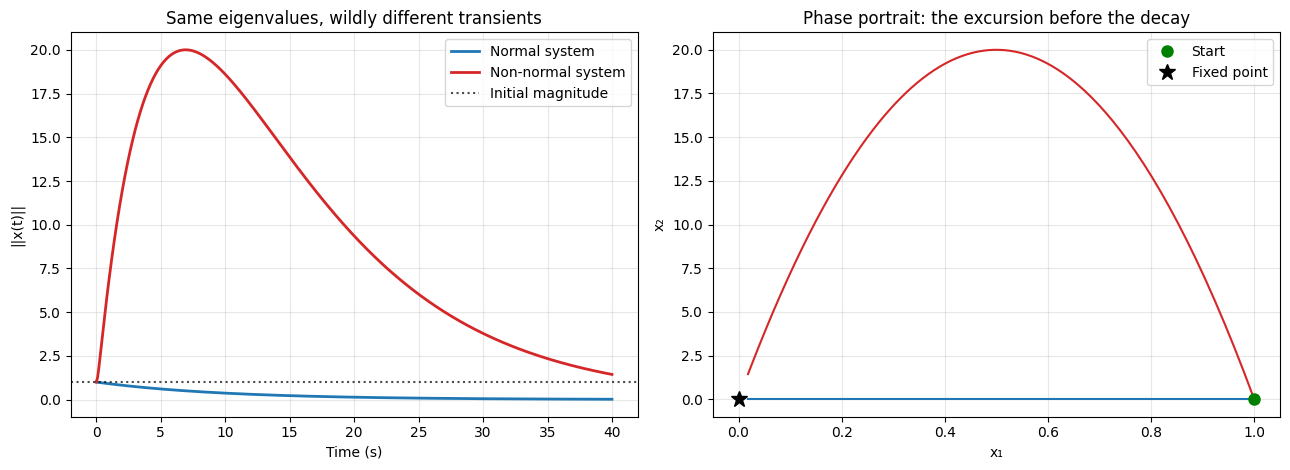

Peak amplification in the non-normal system: 20.0× the initial magnitude
Peak in the normal system:                   1.0×

Both systems end at zero. Only one of them gets there quietly.


In [31]:
# ---- Simulate both from the same initial condition ----

t_nn = np.linspace(0, 40, 400)
x0_nn = np.array([1.0, 0.0])

traj_n  = np.column_stack([expm(A_normal*ti)    @ x0_nn for ti in t_nn])
traj_nn = np.column_stack([expm(A_nonnormal*ti) @ x0_nn for ti in t_nn])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(t_nn, norm(traj_n, axis=0), color='tab:blue', linewidth=2, label='Normal system')
axes[0].plot(t_nn, norm(traj_nn, axis=0), color='tab:red', linewidth=2, label='Non-normal system')
axes[0].axhline(1.0, color='k', linestyle=':', alpha=0.7, label='Initial magnitude')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('||x(t)||')
axes[0].set_title('Same eigenvalues, wildly different transients')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(traj_nn[0], traj_nn[1], color='tab:red', linewidth=1.5)
axes[1].plot(traj_n[0], traj_n[1], color='tab:blue', linewidth=1.5)
axes[1].plot(*x0_nn, 'go', markersize=8, label='Start')
axes[1].plot(0, 0, 'k*', markersize=12, label='Fixed point')
axes[1].set_xlabel('x₁'); axes[1].set_ylabel('x₂')
axes[1].set_title('Phase portrait: the excursion before the decay')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

amp = norm(traj_nn, axis=0).max()
print(f"Peak amplification in the non-normal system: {amp:.1f}× the initial magnitude")
print(f"Peak in the normal system:                   {norm(traj_n, axis=0).max():.1f}×")
print("\nBoth systems end at zero. Only one of them gets there quietly.")

---
# Part IV — Practical Guidance

## 12. Common Gotchas <a id='12'></a>

Nearly every eigen-bug in student analysis code is one of these six.


In [32]:
# ---- Gotcha 1: eigenvectors are COLUMNS ----

C_g = np.array([[4.0, 1.5],
                [1.5, 1.0]])          # Symmetric, for the gotchas that need a covariance
G = np.array([[3.0, 1.0],
              [0.5, 2.0]])            # Non-symmetric, so rows and columns really differ

vals_g, vecs_g = eig(G)
print(f"eigenvectors:\n{vecs_g.round(3)}\n")
print(f"CORRECT — first eigenvector: vecs[:, 0] = {vecs_g[:, 0].round(3)}")
print(f"   A v = λ v?  {np.allclose(G @ vecs_g[:, 0], vals_g[0] * vecs_g[:, 0])}")
print(f"WRONG   — first row:         vecs[0, :] = {vecs_g[0, :].round(3)}")
print(f"   A v = λ v?  {np.allclose(G @ vecs_g[0, :], vals_g[0] * vecs_g[0, :])}")

eigenvectors:
[[ 0.939 -0.591]
 [ 0.344  0.807]]

CORRECT — first eigenvector: vecs[:, 0] = [0.939 0.344]
   A v = λ v?  True
WRONG   — first row:         vecs[0, :] = [ 0.939 -0.591]
   A v = λ v?  False


In [33]:
# ---- Gotcha 2: eig does not sort, eigh sorts ASCENDING ----

print(f"eigh eigenvalues (ascending!):  {eigh(C_g)[0]}")
print(f"So eigh's LAST column is PC1:   {eigh(C_g)[1][:, -1].round(3)}")
print("\nNever index [:, 0] straight out of eigh expecting the top PC.")
print("Sort explicitly (sorted_eig above) and the ambiguity disappears.")

eigh eigenvalues (ascending!):  [0.379 4.621]
So eigh's LAST column is PC1:   [-0.924 -0.383]

Never index [:, 0] straight out of eigh expecting the top PC.
Sort explicitly (sorted_eig above) and the ambiguity disappears.


In [34]:
# ---- Gotcha 3: the sign of an eigenvector is arbitrary ----
# Both v and -v are valid. Runs, machines, and library versions may disagree.

v = eigh(C_g)[1][:, -1]
print(f"NumPy returned: {v.round(3)}")
print(f"Equally valid:  {(-v).round(3)}")
print("\nIf a PC's sign matters for interpretation, FIX it yourself with a convention,")
print("e.g. force the largest-magnitude loading to be positive:")
v_fixed = v * np.sign(v[np.argmax(np.abs(v))])
print(f"After applying that convention: {v_fixed.round(3)}")

NumPy returned: [-0.924 -0.383]
Equally valid:  [0.924 0.383]

If a PC's sign matters for interpretation, FIX it yourself with a convention,
e.g. force the largest-magnitude loading to be positive:
After applying that convention: [0.924 0.383]


In [35]:
# ---- Gotcha 4: eig can hand you complex numbers, and they propagate ----

Rot = np.array([[0.0, -1.0],
                [1.0,  0.0]])          # A 90° rotation: no real direction survives

vals_c = eig(Rot)[0]
print(f"eig on a rotation matrix: {vals_c}  dtype = {vals_c.dtype}")
print(f"Purely imaginary — correct, and it means the matrix rotates every direction.\n")

print("The trap is arithmetic downstream. Comparisons and plots misbehave:")
print(f"  vals.max() is not defined the way you expect for complex numbers")
print(f"  sorting should be by np.abs(vals): {np.abs(vals_c)}")
print(f"\nFor SYMMETRIC matrices you never have to think about this — eigh guarantees")
print(f"real output: eigh(C_g) -> {eigh(C_g)[0]}  dtype = {eigh(C_g)[0].dtype}")
print(f"And if tiny imaginary residues do show up, clean them with np.real_if_close.")

eig on a rotation matrix: [0.+1.j 0.-1.j]  dtype = complex128
Purely imaginary — correct, and it means the matrix rotates every direction.

The trap is arithmetic downstream. Comparisons and plots misbehave:
  vals.max() is not defined the way you expect for complex numbers
  sorting should be by np.abs(vals): [1. 1.]

For SYMMETRIC matrices you never have to think about this — eigh guarantees
real output: eigh(C_g) -> [0.379 4.621]  dtype = float64
And if tiny imaginary residues do show up, clean them with np.real_if_close.


In [36]:
# ---- Gotcha 5: repeated eigenvalues mean the eigenvectors are NOT unique ----
# When two eigenvalues are equal, ANY vector in that plane is an eigenvector.

I2 = np.eye(2)
print(f"Eigenvalues of the identity: {eigh(I2)[0]}  (repeated)")
print(f"NumPy happens to return:\n{eigh(I2)[1]}")
print("\nBut [0.6, 0.8] is just as valid an eigenvector:")
v_alt = np.array([0.6, 0.8])
print(f"  I @ v = {I2 @ v_alt} = 1 × v")
print("\nIn practice: when two PCs explain nearly equal variance, their individual")
print("directions are unreliable. Interpret the PLANE they span, not each axis.")

Eigenvalues of the identity: [1. 1.]  (repeated)
NumPy happens to return:
[[1. 0.]
 [0. 1.]]

But [0.6, 0.8] is just as valid an eigenvector:
  I @ v = [0.6 0.8] = 1 × v

In practice: when two PCs explain nearly equal variance, their individual
directions are unreliable. Interpret the PLANE they span, not each axis.


In [37]:
# ---- Gotcha 6: forgetting to centre before PCA ----

rng = np.random.default_rng(3)
data = rng.multivariate_normal([50, 50], [[4, 3], [3, 4]], size=300)   # Large offset from origin

# Wrong: second moment matrix of uncentred data
C_wrong = data.T @ data / (len(data) - 1)
vals_w, vecs_w = sorted_eig(C_wrong, symmetric=True)

# Right: covariance of centred data
C_right = np.cov(data, rowvar=False)
vals_r, vecs_r = sorted_eig(C_right, symmetric=True)

print(f"Uncentred: PC1 = {vecs_w[:, 0].round(3)}, explains {100*vals_w[0]/vals_w.sum():.1f}%")
print(f"Centred:   PC1 = {vecs_r[:, 0].round(3)}, explains {100*vals_r[0]/vals_r.sum():.1f}%")
print("\nWithout centring, PC1 just points at the data's mean (here ~[0.707, 0.707],")
print("the direction of the point [50, 50]) and 'explains' almost all the variance.")
print("np.cov centres for you. Manual X.T @ X does not.")

Uncentred: PC1 = [0.706 0.708], explains 100.0%
Centred:   PC1 = [-0.715 -0.699], explains 88.3%

Without centring, PC1 just points at the data's mean (here ~[0.707, 0.707],
the direction of the point [50, 50]) and 'explains' almost all the variance.
np.cov centres for you. Manual X.T @ X does not.


### Quick reference

| Symptom | Cause | Fix |
|---|---|---|
| `A @ v` doesn't equal `λ * v` | used a row instead of a column | `vecs[:, i]` |
| PC1 explains 99.9% of everything | data not centred | `np.cov(X, rowvar=False)` or subtract the mean |
| Smallest component came out first | `eigh` sorts ascending | sort explicitly, descending |
| Plot flips between runs | eigenvector sign is arbitrary | apply your own sign convention |
| `ComplexWarning` when plotting | `eig` on a symmetric matrix | use `eigh` |
| Two PCs swap identity between subjects | near-degenerate eigenvalues | interpret the subspace, not the axes |
| Ellipse looks too elongated | scaled axes by $\lambda$ for a covariance | use $\sqrt{\lambda}$ for covariance, $\lambda$ for a mapping matrix |


---
# Part V — Practice

## 13. Exercises <a id='13'></a>

---

### Exercise 1: A Matrix With Only One Eigenvector

The shear matrix $A = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}$ is **defective**: it has a repeated eigenvalue but only *one* independent eigenvector.

1. Compute its eigenvalues by hand from the characteristic equation, then check with `np.linalg.eig`.
2. Print the eigenvector matrix. What do you notice about the two columns?
3. Compute `np.linalg.matrix_rank` of the eigenvector matrix — is it 2?
4. Try to rebuild $A$ as $V\Lambda V^{-1}$. What happens, and why?
5. Apply $A$ to the unit circle and plot the result. Which single direction is left unrotated?


In [38]:
# ---- YOUR CODE HERE ----

### Exercise 2: Variability Ellipses Across Reach Directions

Movement variability is usually elongated along the direction of the reach, and the ellipse orientation should rotate as the target moves.

1. For target directions of 0°, 45°, 90° and 135°, simulate 200 endpoints each with SD 2.5 cm along the reach and 1.0 cm perpendicular to it (build the covariance by rotating `np.diag([2.5**2, 1.0**2])`, as in §5).
2. For each condition, compute the covariance eigendecomposition and extract the PC1 orientation.
3. Plot all four scatters with their 95% ellipses on one set of axes.
4. Plot recovered PC1 orientation against true reach direction. How close to the identity line do you get with 200 trials? With 25 trials?


In [39]:
# ---- YOUR CODE HERE ----

### Exercise 3: How Many Neural Dimensions?

Using the simulation code from §6 as a starting point:

1. Write a function that generates population activity from `n_latent` factors with a specified noise level, and returns the eigenvalue spectrum.
2. Sweep `n_latent` from 1 to 10 and plot the participation ratio against the true number of latents. Where does the estimate start to break down?
3. Sweep the noise SD from 0.5 to 10 with `n_latent = 3` fixed. At what noise level does the participation ratio stop recovering 3?
4. Repeat point 3 with 20 neurons instead of 60. Does recording more neurons help?


In [40]:
# ---- YOUR CODE HERE ----

### Exercise 4: Fitting Two Timescales (Challenge)

1. Take the two-state model from §9 and simulate an adaptation block with trial-to-trial motor noise added to the output (`rng.normal(0, 0.05)`).
2. Sweep the fast retention factor $A_f$ from 0.2 to 0.99, holding everything else fixed. For each value, compute the closed-loop eigenvalues and the two time constants.
3. Plot the two time constants against $A_f$. What happens to the *ratio* of the timescales as $A_f \to A_s$?
4. Simulate the error-clamp phase at $A_f = 0.4$, $0.7$, and $0.9$. How does the size and timing of the spontaneous recovery peak depend on the separation between the eigenvalues?


In [41]:
# ---- YOUR CODE HERE ----

### Exercise 5: When Does Feedback Become Tremor? (Challenge)

A simplified discrete-time model of a delayed feedback controller regulating limb position:

$$\mathbf{x}_{n+1} = \begin{pmatrix} 0 & 1 \\ -g & 1.6 \end{pmatrix} \mathbf{x}_n$$

where $g$ is the feedback gain. Remember that discrete-time stability requires $|\lambda| < 1$ for **every** eigenvalue.

1. Sweep $g$ from 0 to 1.5 and compute the eigenvalues at each value.
2. Plot $\max_i |\lambda_i|$ against $g$ and mark where it crosses 1.
3. Plot the eigenvalues in the complex plane together with the unit circle. Where do they exit?
4. Simulate 60 trials from $\mathbf{x}_0 = [1, 0]$ at a gain below, at, and above the critical value. Describe each behaviour in words.
5. At what gain do the eigenvalues first become complex, and what does the system's behaviour look like between that point and the stability limit?


In [42]:
# ---- YOUR CODE HERE ----

---
## 14. Summary & Further Reading <a id='14'></a>

### What You Learned

| Task | NumPy / SciPy | Notes |
|---|---|---|
| **Eigenvalues only** | `np.linalg.eigvals(A)` | Faster when you don't need vectors |
| **Eigenvalues + vectors** | `np.linalg.eig(A)` | Vectors are **columns**; output is **unsorted** |
| **Symmetric matrices** | `np.linalg.eigh(A)` | Real, orthonormal, **ascending** — always prefer this |
| **Symmetric, values only** | `np.linalg.eigvalsh(A)` | Stability check on the symmetric part |
| **Covariance matrix** | `np.cov(X, rowvar=False)` | Centres for you; rows = observations |
| **Confidence ellipse** | `eigh` + `scipy.stats.chi2.ppf` | Axes scale as $\sqrt{\lambda}$ |
| **Matrix exponential** | `scipy.linalg.expm(A*t)` | Solves $\dot{x}=Ax$ without modal algebra |
| **Rebuild from parts** | `V @ np.diag(w) @ inv(V)` | `V.T` instead of `inv(V)` if symmetric |
| **Effective dimensionality** | $(\sum\lambda)^2 / \sum\lambda^2$ | Participation ratio; no threshold needed |

### The Two Big Ideas

| If your matrix is... | Eigenvectors mean | Eigenvalues mean |
|---|---|---|
| A **covariance** matrix ($\Sigma$) | principal axes of variability | variance along each axis ($\sqrt{\lambda}$ = SD) |
| A **dynamics** matrix ($A$) | modes of the system | decay rate / oscillation / growth |
| A **stiffness** matrix ($K$) | stiffest and most compliant directions | stiffness in N/m along each |
| An **inertia** matrix ($M$) | axes of the inertia ellipse | effective mass in each direction |

### Stability Cheat Sheet

| System | Stable when | Time constant |
|---|---|---|
| Continuous $\dot{x} = Ax$ | $\text{Re}(\lambda_i) < 0$ for all $i$ | $\tau = -1/\max_i \text{Re}(\lambda_i)$ |
| Discrete $x_{n+1} = Ax_n$ | $\lvert\lambda_i\rvert < 1$ for all $i$ | $\tau = -1/\ln \max_i \lvert\lambda_i\rvert$ trials |

### Further Reading

- [3Blue1Brown — Eigenvectors and eigenvalues](https://www.youtube.com/watch?v=PFDu9oVAE-g) — 17 minutes, and the best geometric intuition available anywhere
- [NumPy linear algebra reference](https://numpy.org/doc/stable/reference/routines.linalg.html) — the full API
- [Strang — *Introduction to Linear Algebra*](https://math.mit.edu/~gs/linearalgebra/), Ch. 6 — the standard treatment
- [Smith, Ghazizadeh & Shadmehr (2006)](https://doi.org/10.1371/journal.pbio.0040179) — the two-state model and spontaneous recovery (§9)
- [Cunningham & Yu (2014)](https://doi.org/10.1038/nn.3776) — dimensionality reduction for population recordings, and how to interpret it (§6–7)
- [Churchland et al. (2012)](https://doi.org/10.1038/nature11129) — rotational dynamics in motor cortex, found with PCA/jPCA
- [Murphy & Miller (2009)](https://doi.org/10.1016/j.neuron.2009.02.005) — balanced amplification and non-normal cortical dynamics (§11)
- Mussa-Ivaldi, Hogan & Bizzi (1985), *J Neurosci* 5:2732–2743 — the original hand stiffness ellipses (§10)
- [Shadmehr & Wise — *Computational Neurobiology of Reaching and Pointing*](https://www.shadmehrlab.org/book) — dynamics and control in context

### What's Next?

With eigendecomposition in hand, you are ready for:
- **jPCA and dynamical systems analysis** of population activity — eigenvalues of a fitted rotation matrix
- **Optimal feedback control (LQR)** — stability of the closed-loop matrix $A - BK$
- **Factor analysis and GPFA** — dimensionality reduction that models private noise per neuron
- **Uncontrolled manifold analysis** — variance decomposed relative to a task-relevant subspace

---

*Find the directions that don't move, and the rest of the problem gets a lot smaller.*
